In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [44]:
df = pd.read_csv('C:\\Users\\FDRA\\Documents\\DATA SCIENCE\\CWHDS\\ScikitLearn\\train.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [45]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [46]:
df.shape

(891, 3)

In [47]:
df.dropna(inplace=True)


In [48]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [50]:
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
clf = DecisionTreeClassifier()

In [55]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


In [56]:
accuracy_score(y_test, y_pred)

0.6293706293706294

In [58]:
np.mean(cross_val_score(clf, X, y, cv=10, scoring='accuracy'))

np.float64(0.6330790297339594)

In [59]:
kbin_age = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')


In [60]:
trf = ColumnTransformer([
    ('kbin_age', kbin_age, [0]),
    ('kbin_fare', kbin_fare, [1])
])


In [61]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [66]:
trf.named_transformers_["kbin_fare"].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [67]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_binned': X_train_trf[:, 0],
    'fare': X_train['Fare'],
    'fare_binned': X_train_trf[:, 1]
})

In [68]:
output['age_labels'] = pd.cut(x = X_train['Age'], bins = trf.named_transformers_["kbin_age"].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x = X_train['Fare'], bins = trf.named_transformers_["kbin_fare"].bin_edges_[0].tolist())

In [69]:
output.sample(10)

,age,age_binned,fare,fare_binned,age_labels,fare_labels
161,40.0,7.0,15.7500,5.0,"(36.0, 42.0]","(13.0, 15.75]"
707,42.0,8.0,26.2875,6.0,"(36.0, 42.0]","(26.0, 29.125]"
599,49.0,8.0,56.9292,8.0,"(42.0, 50.0]","(51.479, 82.171]"
679,36.0,7.0,512.3292,9.0,"(32.0, 36.0]","(82.171, 512.329]"
249,54.0,9.0,26.0000,6.0,"(50.0, 80.0]","(15.75, 26.0]"
785,25.0,4.0,7.2500,0.0,"(22.0, 25.0]","(0.0, 7.75]"
423,28.0,4.0,14.4000,4.0,"(25.0, 28.5]","(13.0, 15.75]"
361,29.0,5.0,27.7208,6.0,"(28.5, 32.0]","(26.0, 29.125]"
13,39.0,7.0,31.2750,7.0,"(36.0, 42.0]","(29.125, 51.479]"
548,33.0,6.0,20.5250,5.0,"(32.0, 36.0]","(15.75, 26.0]"


In [70]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

In [71]:
accuracy_score(y_test, y_pred2)

0.6223776223776224

In [72]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(clf, X_trf, y, cv=10, scoring='accuracy'))

np.float64(0.6807316118935838)

In [73]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('kbin_age', kbin_age, [0]),
        ('kbin_fare', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(clf, X_trf, y, cv=10, scoring='accuracy')))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(X["Age"])
    plt.title("Age Before Distribution")
    
    plt.subplot(1, 2, 2)
    plt.hist(X_trf[:, 0], color='red')
    plt.title("Age After Distribution")
    plt.show()
    

C:\Users\FDRA\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\FDRA\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6723982785602504


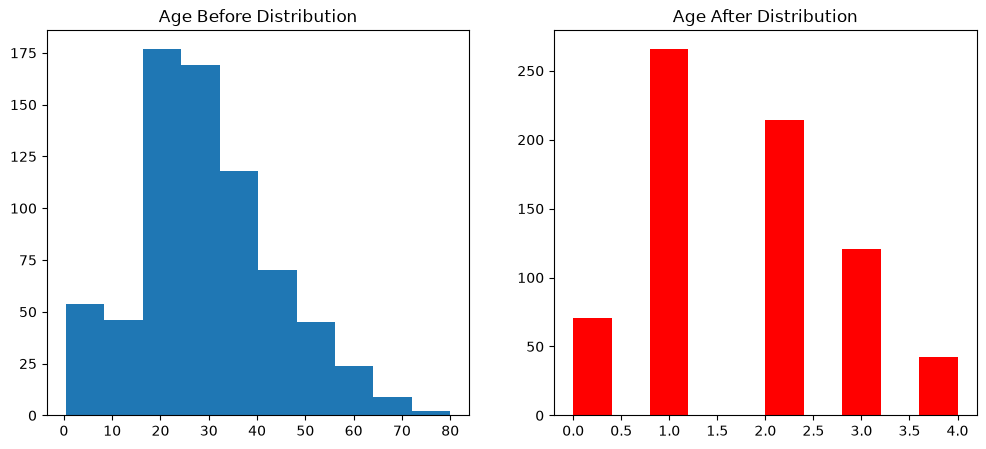

In [77]:
discretize(5, strategy='kmeans')